In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Tải dữ liệu

In [ ]:
!wget https://raw.githubusercontent.com/ppp123-a11y/Sleep-Health-and-Lifestyle/main/Sleep_health_and_lifestyle_dataset.csv
print("Đã tải dữ liệu!")

--2025-05-07 09:38:51--  https://raw.githubusercontent.com/ppp123-a11y/Sleep-Health-and-Lifestyle/main/Sleep_health_and_lifestyle_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24137 (24K) [text/plain]
Saving to: ‘Sleep_health_and_lifestyle_dataset.csv’

Sleep_health_and_li 100%[===================>]  23.57K  --.-KB/s    in 0.002s  

2025-05-07 09:38:52 (9.68 MB/s) - ‘Sleep_health_and_lifestyle_dataset.csv’ saved [24137/24137]

Đã tải dữ liệu!


file dữ liệu được tải về sẽ có tên là Sleep_health_and_lifestyle_dataset.csv

# Phân tích khám phá dữ liệu

## Tổng quan về dữ liệu

**MÔ TẢ**

Person ID: Mã định danh cho mỗi cá nhân.

Gender: Giới tính của người đó (Nam/Nữ).

Age: Tuổi của người đó tính theo năm.

Occupation: Nghề nghiệp hoặc công việc của người đó.

Sleep Duration (hours): Số giờ người đó ngủ mỗi ngày.

Quality of Sleep (scale: 1-10): Đánh giá chủ quan về chất lượng giấc ngủ, theo thang điểm từ 1 đến 10.

Physical Activity Level (minutes/day): Số phút người đó tham gia vào hoạt động
thể chất mỗi ngày.

Stress Level (scale: 1-10): Đánh giá chủ quan về mức độ căng thẳng mà người đó trải qua, theo thang điểm từ 1 đến 10.

BMI Category: Phân loại chỉ số BMI của người đó (Ví dụ: Gầy, Bình thường, Thừa cân).

Blood Pressure (systolic/diastolic): Chỉ số huyết áp của người đó, được biểu thị dưới dạng huyết áp tâm thu trên huyết áp tâm trương.

Heart Rate (bpm): Nhịp tim khi nghỉ ngơi của người đó, tính bằng số nhịp mỗi phút.

Daily Steps: Số bước chân người đó đi mỗi ngày.

Sleep Disorder: Sự hiện diện hoặc vắng mặt của rối loạn giấc ngủ ở người đó (Không có, Mất ngủ, Ngưng thở khi ngủ).

In [ ]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(np.float64)
df = df.drop(columns=['Blood Pressure']) # Vì đã tách Systolic và Diastolic nên bỏ đi Blood Pressure

cols = list(df.columns)
cols.remove('Sleep Disorder')
cols.append('Sleep Disorder')
df = df[cols]
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,Diastolic,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,126.0,83.0,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,125.0,80.0,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,125.0,80.0,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140.0,90.0,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140.0,90.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,140.0,95.0,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,140.0,95.0,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,140.0,95.0,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,140.0,95.0,Sleep Apnea


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
 13  Sleep Disorder           155 non-null    object 
dtypes: float64(3), int64(7), o

In [ ]:
df.describe(include='all')

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,Diastolic,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374.000000,374.000000,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,NaN,NaN,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,NaN,NaN,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,70.165775,6816.844920,128.553476,84.649733,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,4.135676,1617.915679,7.748118,6.161611,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,65.000000,3000.000000,115.000000,75.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,68.000000,5600.000000,125.000000,80.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,70.000000,7000.000000,130.000000,85.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,72.000000,8000.000000,135.000000,90.000000,NaN


## Phân tích đơn biến

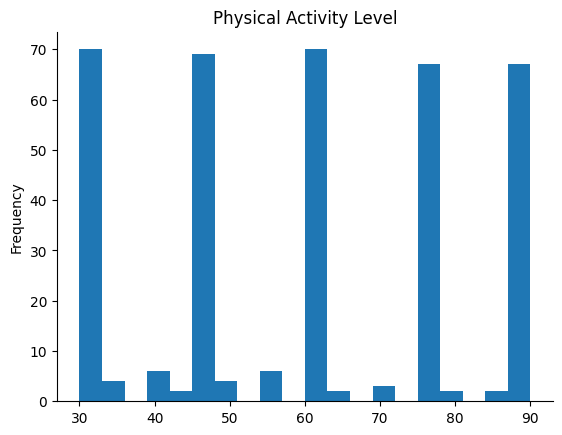

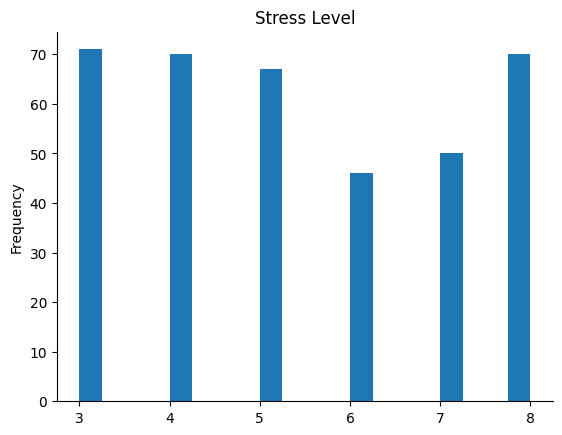

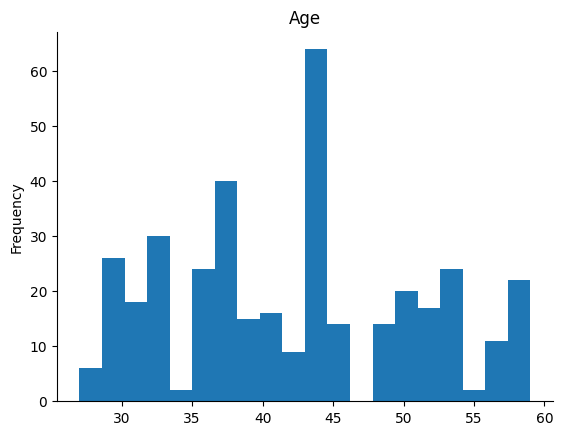

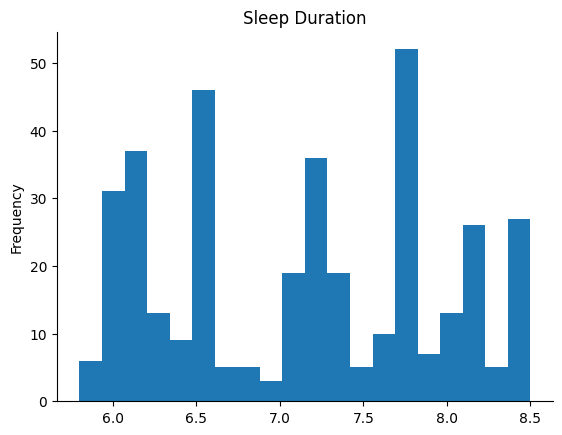

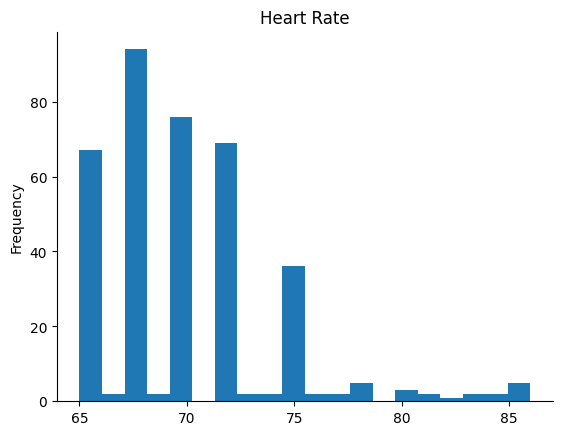

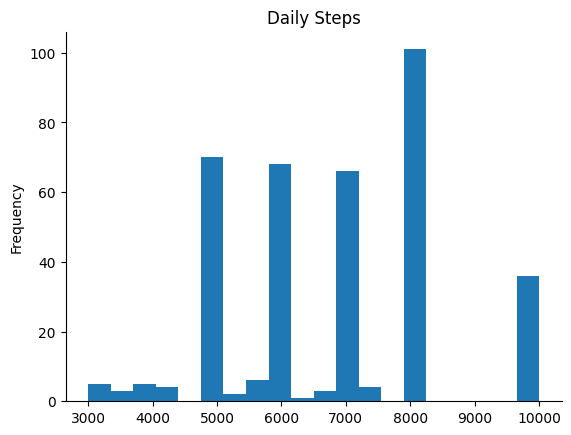

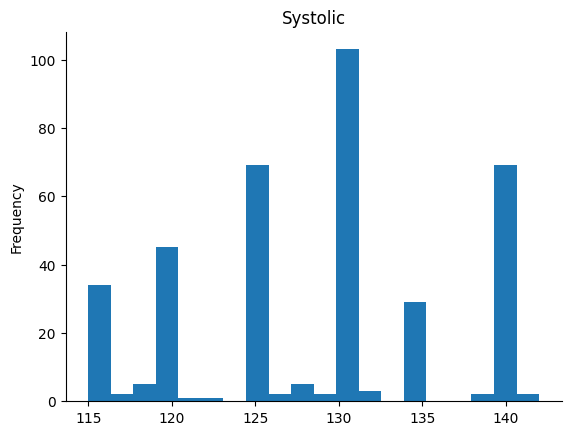

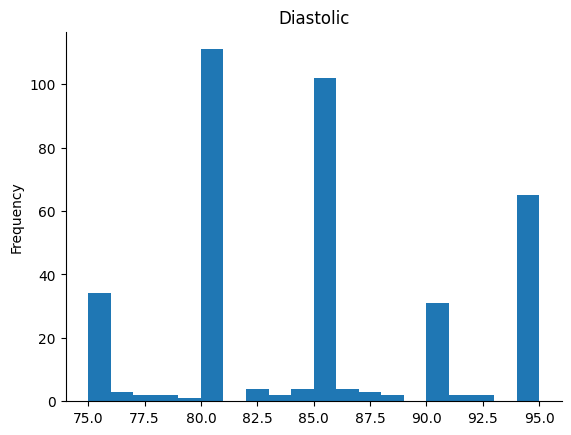

In [ ]:
for col in 'Physical Activity Level', 'Stress Level', 'Age', 'Sleep Duration', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic':
  df[col].plot(kind='hist', bins=20, title=col)
  plt.gca().spines[['top', 'right',]].set_visible(False)
  plt.show()

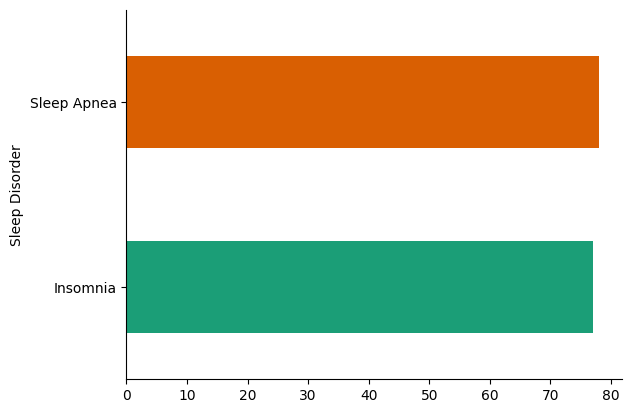

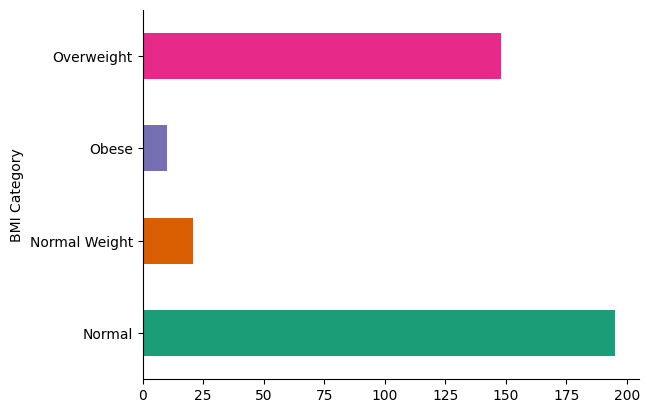

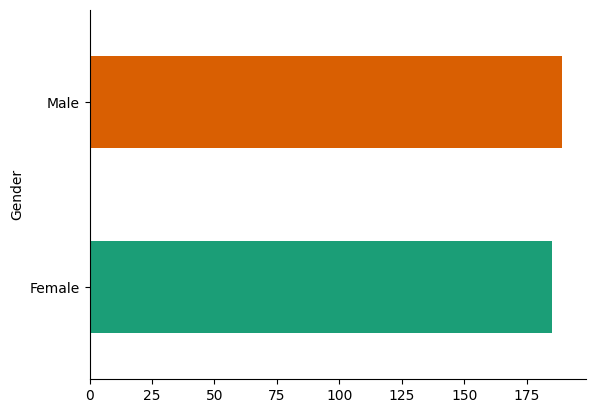

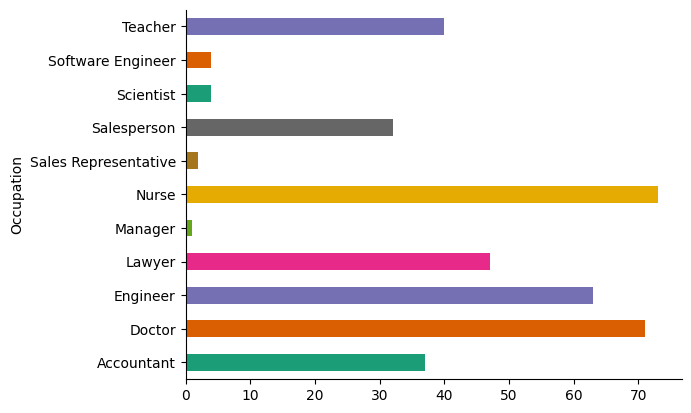

In [ ]:
for col in 'Sleep Disorder', 'BMI Category', 'Gender', 'Occupation':
  df.groupby(col).size().plot(kind='barh', color=sns.color_palette('Dark2'))
  plt.gca().spines[['top', 'right',]].set_visible(False)
  plt.show()

## Phân tích đa biến

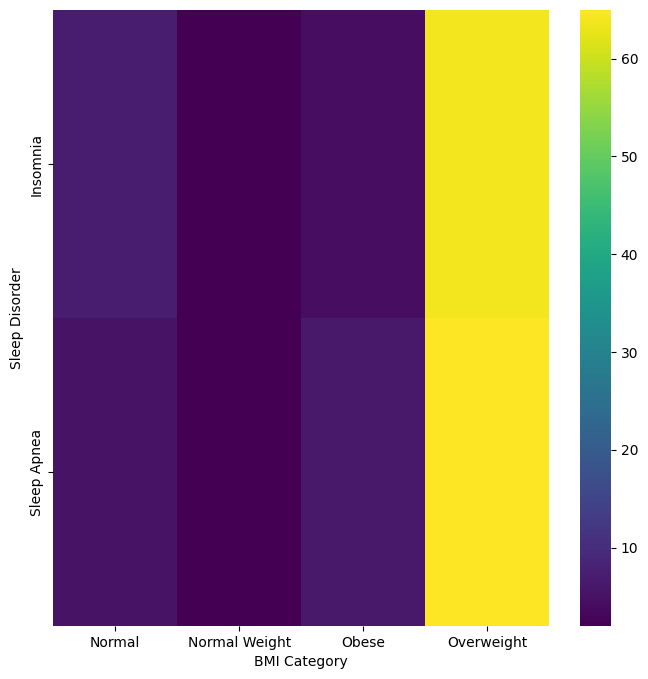

In [ ]:
# @title Sự ảnh hưởng của Lượng mỡ trong cơ thể đến rối loạn giấc ngủ

plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Sleep Disorder'].value_counts()
    for x_label, grp in df.groupby('BMI Category')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('BMI Category')
_ = plt.ylabel('Sleep Disorder')

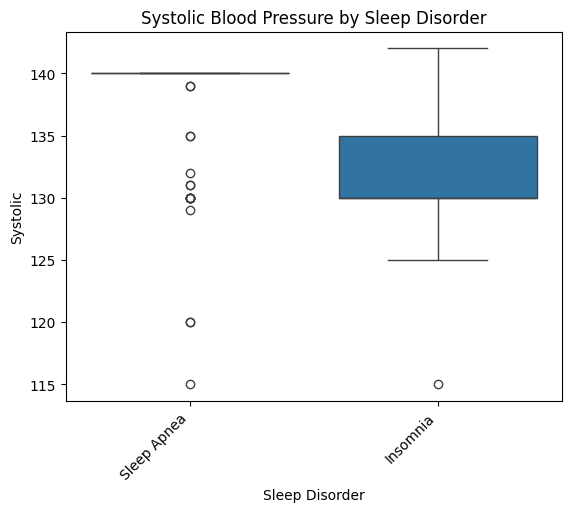

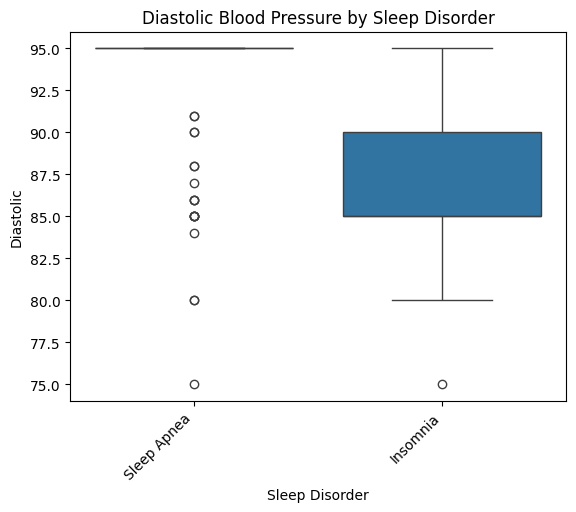

In [ ]:
# @title Sự ảnh hưởng của huyết áp đến rối loạn giấc ngủ

sns.boxplot(x='Sleep Disorder', y='Systolic', data=df)
plt.title('Systolic Blood Pressure by Sleep Disorder')
plt.xticks(rotation=45, ha='right')
plt.show()

sns.boxplot(x='Sleep Disorder', y='Diastolic', data=df)
plt.title('Diastolic Blood Pressure by Sleep Disorder')
plt.xticks(rotation=45, ha='right')
plt.show()

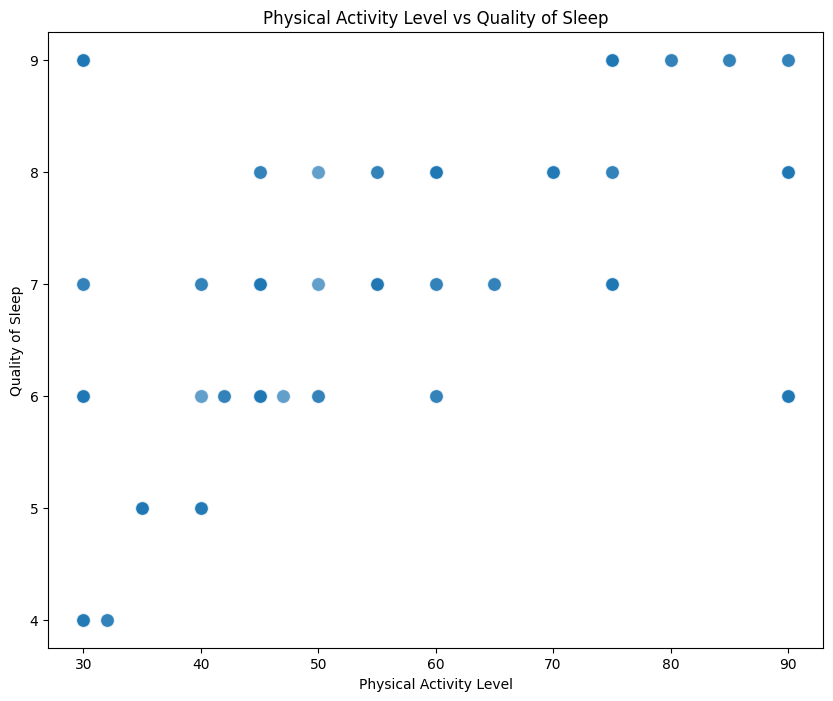

In [ ]:
# @title Mối quan hệ mức độ hoạt động thể chất và chất lượng giấc ngủ
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x="Physical Activity Level", y="Quality of Sleep", s=100, alpha=0.7)
plt.title("Physical Activity Level vs Quality of Sleep")
plt.xlabel("Physical Activity Level")
plt.ylabel("Quality of Sleep")
plt.show()

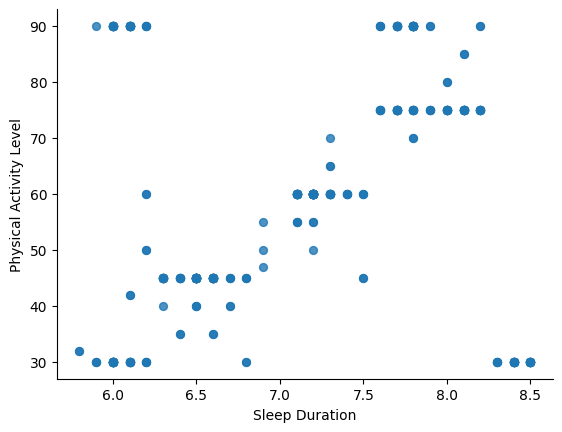

In [ ]:
# @title Mối quan hệ giữa mức độ hoạt động thể chất và cường độ giấc ngủ

df.plot(kind='scatter', x='Sleep Duration', y='Physical Activity Level', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

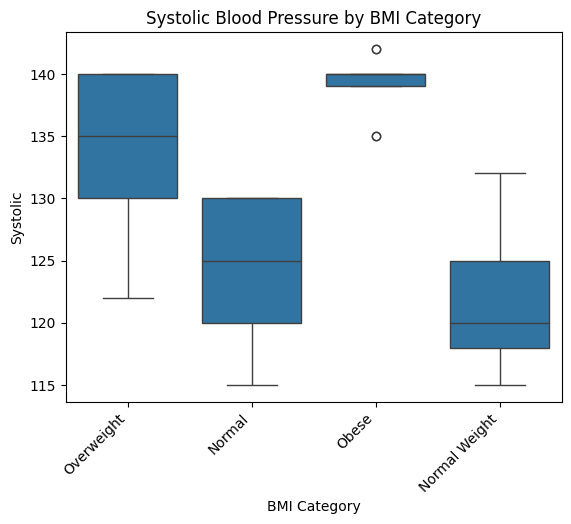

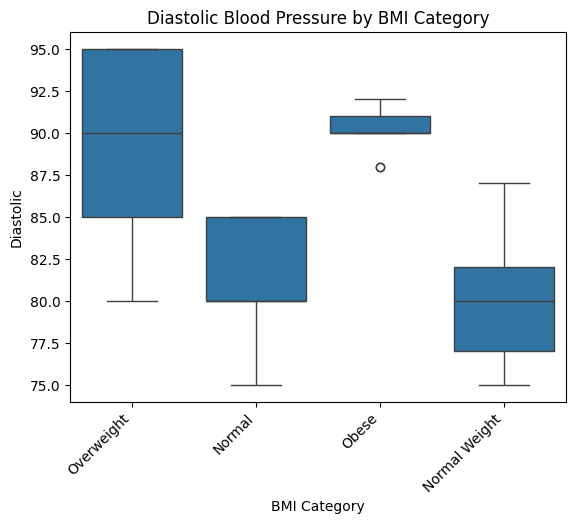

In [ ]:
# @title Mối liên quan giữa Huyết áp và Lượng mỡ trong cơ thể

sns.boxplot(x='BMI Category', y='Systolic', data=df)
plt.title('Systolic Blood Pressure by BMI Category')
plt.xticks(rotation=45, ha='right')
plt.show()

sns.boxplot(x='BMI Category', y='Diastolic', data=df)
plt.title('Diastolic Blood Pressure by BMI Category')
plt.xticks(rotation=45, ha='right')
plt.show()

<ipython-input-14-07a5239283cf>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Sleep Duration', y='Gender', inner='stick', palette='Dark2')


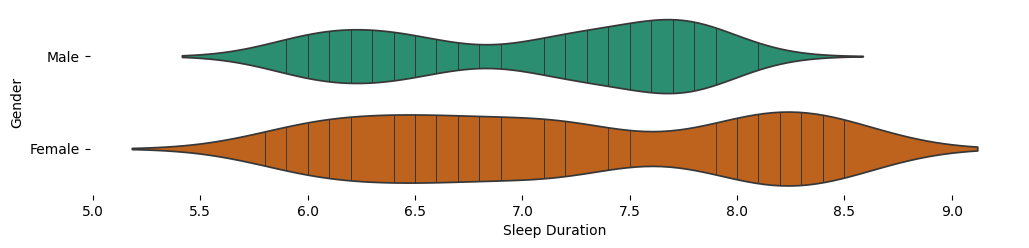

In [ ]:
# @title Cường độ giấc ngủ của giới tính

figsize = (12, 1.2 * len(df['Gender'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Sleep Duration', y='Gender', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

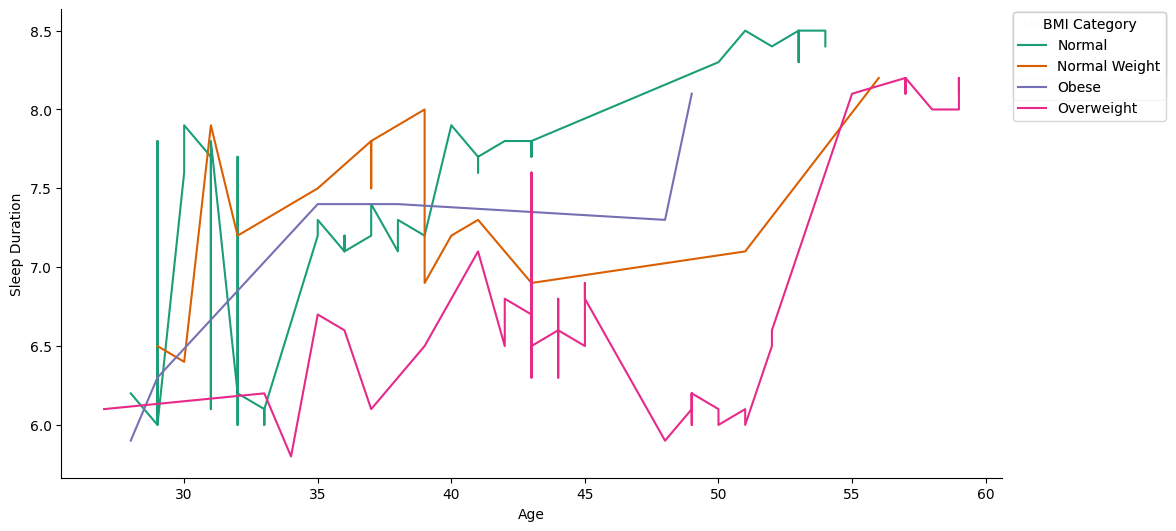

In [ ]:
# @title Cường độ giấc ngủ trong tuổi tác

def _plot_series(series, series_name, series_index=0):
  palette = sns.color_palette('Dark2')
  xs = series['Age']
  ys = series['Sleep Duration']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Age', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('BMI Category')):
  _plot_series(series, series_name, i)
  fig.legend(title='BMI Category', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Age')
_ = plt.ylabel('Sleep Duration')

<ipython-input-16-81ef03521727>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Occupation", y="Stress Level", palette="coolwarm", ci=None)
<ipython-input-16-81ef03521727>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Occupation", y="Stress Level", palette="coolwarm", ci=None)


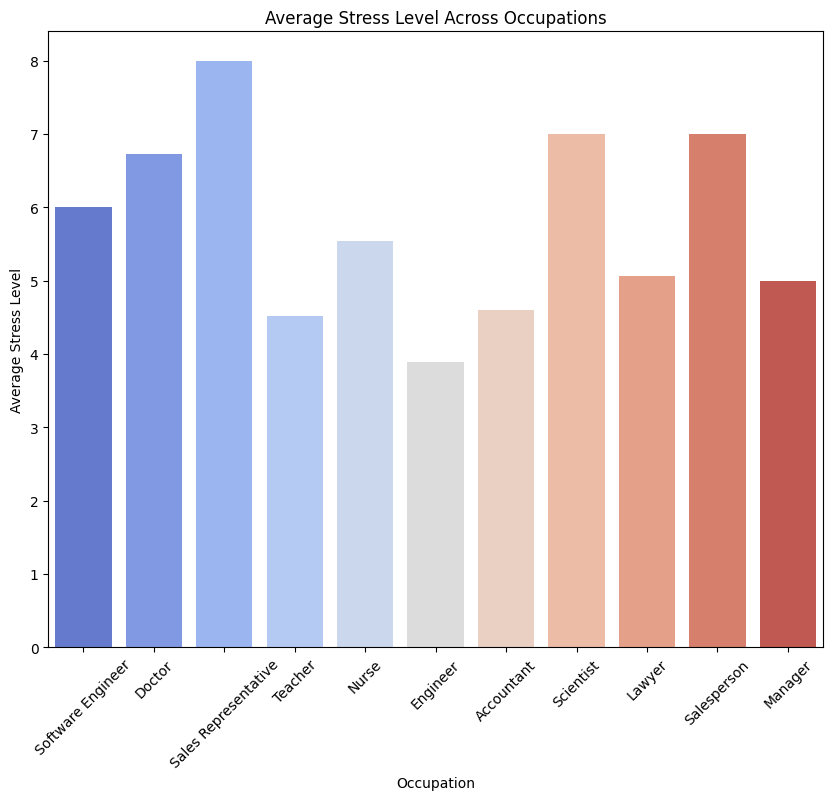

In [ ]:
# @title Căng thẳng trong ngành việc làm

plt.figure(figsize=(10, 8))
sns.barplot(data=df, x="Occupation", y="Stress Level", palette="coolwarm", ci=None)
plt.title("Average Stress Level Across Occupations")
plt.xlabel("Occupation")
plt.ylabel("Average Stress Level")
plt.xticks(rotation=45)
plt.show()

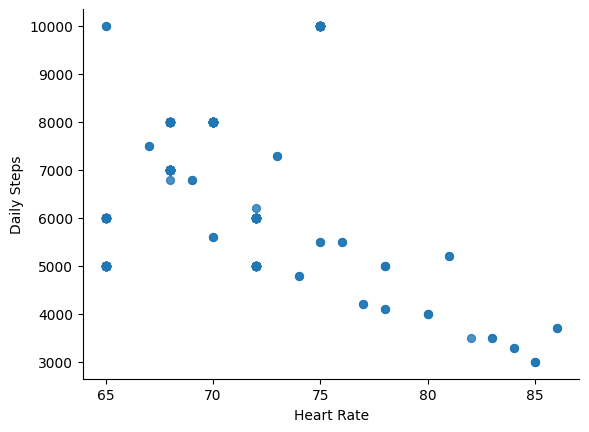

In [ ]:
# @title Nhịp tim qua Số bước chân

df.plot(kind='scatter', x='Heart Rate', y='Daily Steps', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

<ipython-input-18-0c304a68690f>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Age', y='Sleep Disorder', inner='stick', palette='Dark2')


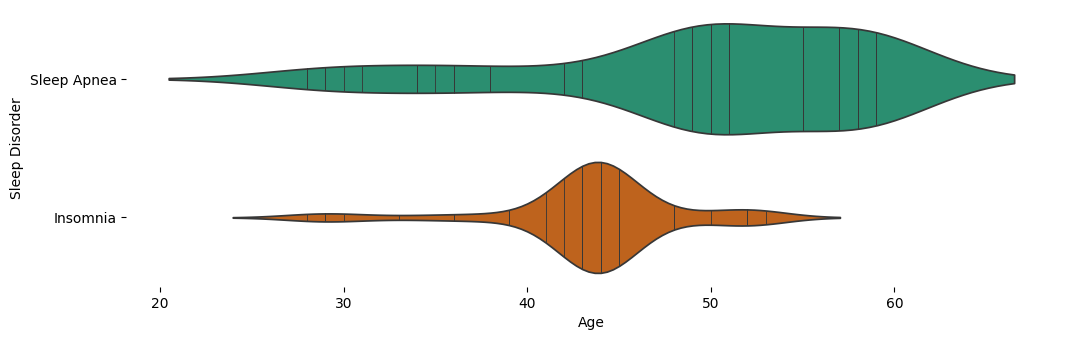

In [ ]:
# @title Rối loạn giấc ngủ trong tuổi tác

figsize = (12, 1.2 * len(df['Sleep Disorder'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Age', y='Sleep Disorder', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

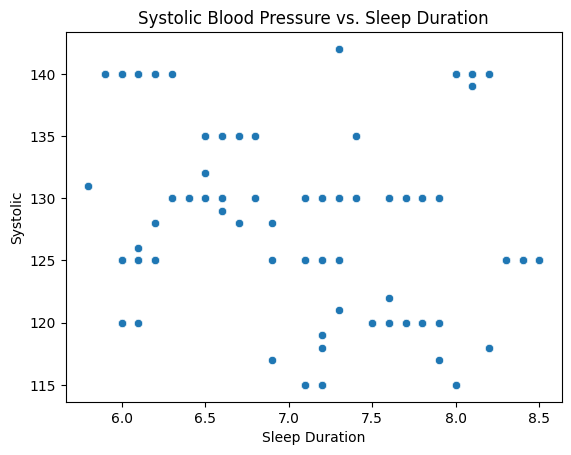

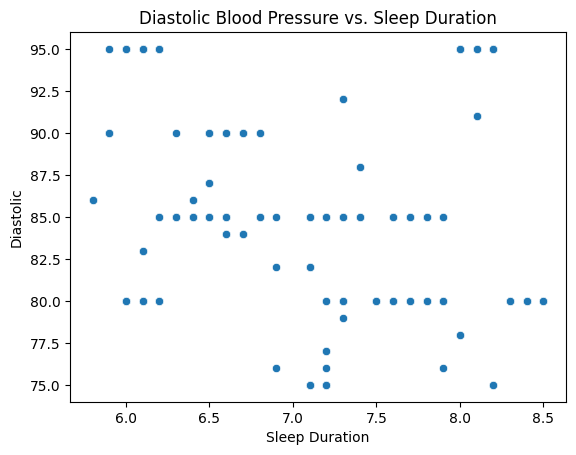

In [ ]:
sns.scatterplot(x='Sleep Duration', y='Systolic', data=df)
plt.title('Systolic Blood Pressure vs. Sleep Duration')
plt.show()

sns.scatterplot(x='Sleep Duration', y='Diastolic', data=df)
plt.title('Diastolic Blood Pressure vs. Sleep Duration')
plt.show()

## Kiểm tra giá trị thiếu

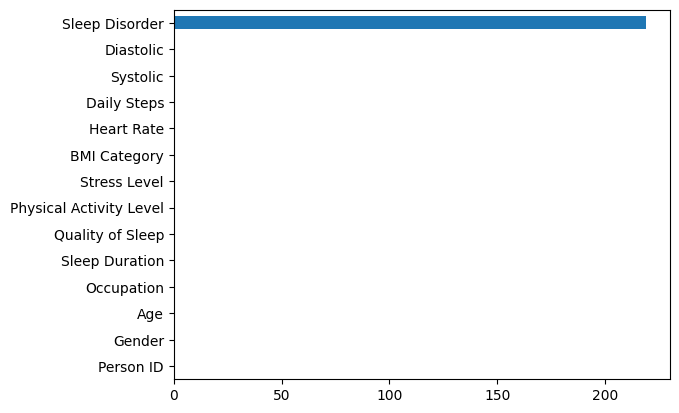

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Heart Rate,0


In [ ]:
df.isna().sum().plot(kind='barh') # what kind ? -> barh : horinzontal bar
plt.show()
df.isna().sum()

## Kiểm tra giá trị bị trùng lặp

In [ ]:
df[df.duplicated()]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,Diastolic,Sleep Disorder


In [ ]:
print("Tổng số lượng giá trị bị trùng lặp:",df.duplicated().sum())

Tổng số lượng giá trị bị trùng lặp: 0


## Kiểm tra giá trị âm của cột số

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns # float, int

# Kiểm tra xem có giá trị âm hay không
for col in numerical_cols:
  if (df[col] < 0).any():
    print(f"Cột '{col}' chứa giá trị âm.")
  else:
    print(f"Cột '{col}' KHÔNG chứa giá trị âm.")

Cột 'Person ID' KHÔNG chứa giá trị âm.
Cột 'Age' KHÔNG chứa giá trị âm.
Cột 'Sleep Duration' KHÔNG chứa giá trị âm.
Cột 'Quality of Sleep' KHÔNG chứa giá trị âm.
Cột 'Physical Activity Level' KHÔNG chứa giá trị âm.
Cột 'Stress Level' KHÔNG chứa giá trị âm.
Cột 'Heart Rate' KHÔNG chứa giá trị âm.
Cột 'Daily Steps' KHÔNG chứa giá trị âm.
Cột 'Systolic' KHÔNG chứa giá trị âm.
Cột 'Diastolic' KHÔNG chứa giá trị âm.


# Tiền xử lý dữ liệu

## Xử lý dữ liệu theo ngữ cảnh

In [ ]:
# Điền các NaN trong cột 'Sleep Disorder' thành None cho đúng với bản gốc
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Biến đổi giá trị ngữ cảnh Normal thành Normal Weight, Obsese thành Overweight
df['BMI Category'] = df['BMI Category'].replace({'Normal': 'Normal Weight', 'Obese': 'Overweight'})

## Chia dữ liệu

Chia dữ liệu trước khi xử lý dữ liệu để đảm bảo tập test vẫn giữ bản chất

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Nối X_train và y_train lại với nhau thành 1 tập train, tương tự với tập test
df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

## Xử lý giá trị

In [ ]:
from sklearn.impute import SimpleImputer

# Xác định các cột numeric và categorical
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Imputation cho biến numeric: sử dụng trung vị
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
test_df[numeric_cols] = num_imputer.transform(test_df[numeric_cols])

# Imputation cho biến categorical: sử dụng giá trị mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
test_df[categorical_cols] = cat_imputer.transform(test_df[categorical_cols])

# Loại bỏ các đối tượng trùng lặp
df.drop_duplicates(inplace=True)

In [ ]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,Diastolic,Sleep Disorder
92,93.0,Male,35.0,Software Engineer,7.5,8.0,60.0,5.0,Normal Weight,70.0,8000.0,120.0,80.0,None
69,70.0,Female,33.0,Scientist,6.2,6.0,50.0,6.0,Overweight,76.0,5500.0,128.0,85.0,None
347,348.0,Female,57.0,Nurse,8.2,9.0,75.0,3.0,Overweight,68.0,7000.0,140.0,95.0,Sleep Apnea
96,97.0,Female,36.0,Accountant,7.2,8.0,60.0,4.0,Normal Weight,68.0,7000.0,115.0,75.0,None
143,144.0,Female,38.0,Accountant,7.1,8.0,60.0,4.0,Normal Weight,68.0,7000.0,115.0,75.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,72.0,Male,33.0,Doctor,6.1,6.0,30.0,8.0,Normal Weight,72.0,5000.0,125.0,80.0,None
106,107.0,Female,37.0,Nurse,6.1,6.0,42.0,6.0,Overweight,77.0,4200.0,126.0,83.0,None
270,271.0,Female,49.0,Nurse,6.1,6.0,90.0,8.0,Overweight,75.0,10000.0,140.0,95.0,Sleep Apnea
348,349.0,Female,57.0,Nurse,8.2,9.0,75.0,3.0,Overweight,68.0,7000.0,140.0,95.0,Sleep Apnea


In [ ]:
test_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,Diastolic,Sleep Disorder
329,330.0,Female,53.0,Engineer,8.5,9.0,30.0,3.0,Normal Weight,65.0,5000.0,125.0,80.0,None
33,34.0,Male,31.0,Doctor,6.1,6.0,30.0,8.0,Normal Weight,72.0,5000.0,125.0,80.0,None
15,16.0,Male,29.0,Doctor,6.0,6.0,30.0,8.0,Normal Weight,70.0,8000.0,120.0,80.0,None
325,326.0,Female,53.0,Engineer,8.5,9.0,30.0,3.0,Normal Weight,65.0,5000.0,125.0,80.0,None
57,58.0,Male,32.0,Doctor,6.0,6.0,30.0,8.0,Normal Weight,72.0,5000.0,125.0,80.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,297.0,Female,50.0,Nurse,6.1,6.0,90.0,8.0,Overweight,75.0,10000.0,140.0,95.0,Sleep Apnea
355,356.0,Female,58.0,Nurse,8.0,9.0,75.0,3.0,Overweight,68.0,7000.0,140.0,95.0,Sleep Apnea
334,335.0,Female,54.0,Engineer,8.4,9.0,30.0,3.0,Normal Weight,65.0,5000.0,125.0,80.0,None
147,148.0,Male,39.0,Engineer,6.5,5.0,40.0,7.0,Overweight,80.0,4000.0,132.0,87.0,Insomnia


## Xử lý đặc trưng

In [ ]:
# Loại bỏ đặc trưng không quan trọng
df = df.drop(columns=['Person ID'])
test_df = test_df.drop(columns=['Person ID'])

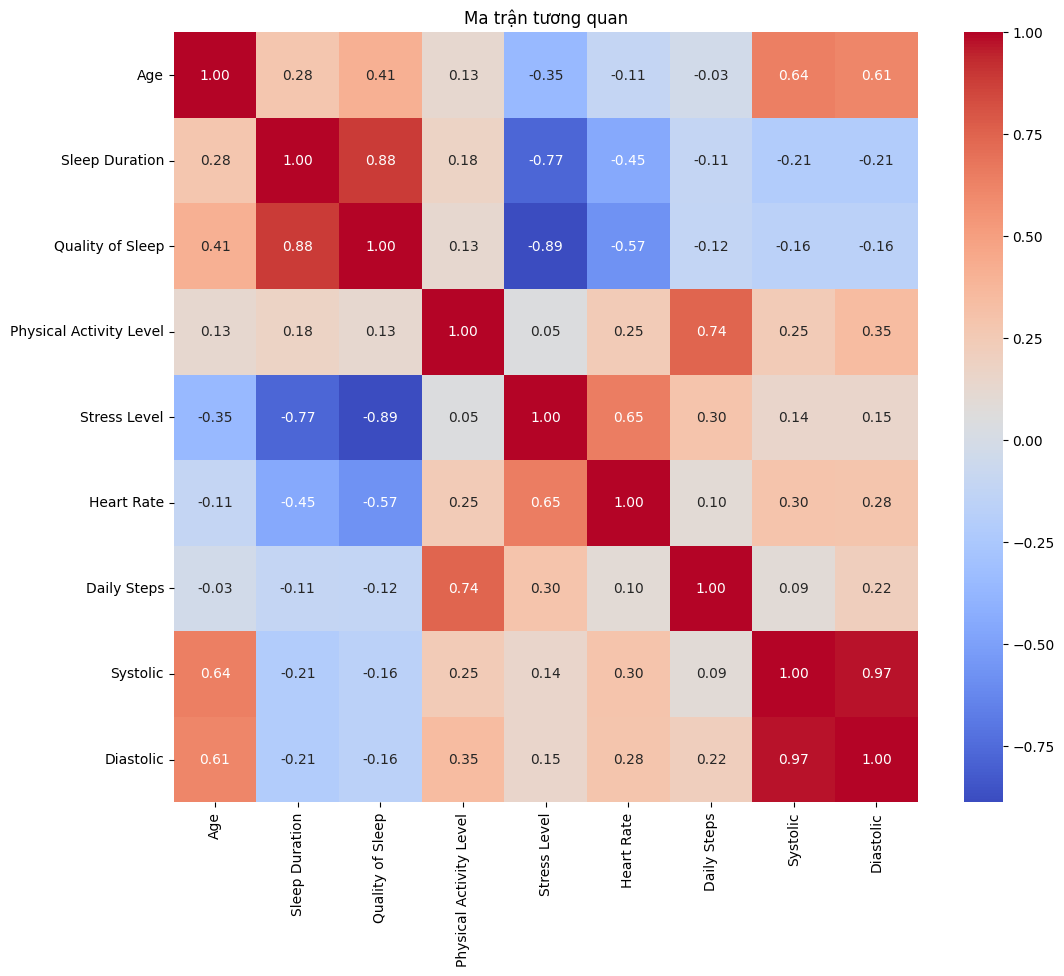

In [ ]:
# Chọn ra các cột số
numerical_df = df.select_dtypes(include=['number'])

# Tính toán ma trận tương quan
correlation_matrix = numerical_df.corr()

# Hiển thị ma trận tương quan bằng Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan')
plt.show()

In [ ]:
# Lấy danh sách các thuộc tính có độ tương quan cao hơn 0.8, trừ Systolic và Diastolic
highly_correlated_features = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        # Kiểm tra điều kiện độ tương quan và loại trừ Systolic, Diastolic
        if abs(correlation_matrix.iloc[i, j]) > 0.8 and correlation_matrix.columns[i] not in ('Systolic', 'Diastolic') and correlation_matrix.columns[j] not in ('Systolic', 'Diastolic'):
            colname = correlation_matrix.columns[i]
            highly_correlated_features.add(colname)

# Loại bỏ các thuộc tính khỏi DataFrame (trừ Systolic và Diastolic)
df = df.drop(columns=highly_correlated_features)
test_df = test_df.drop(columns=highly_correlated_features)
print(f'Đã loại bỏ thuộc tính: {highly_correlated_features}')

Đã loại bỏ thuộc tính: {'Stress Level', 'Quality of Sleep'}


## One-Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Gender', 'Occupation', 'BMI Category'] # Ngoài trừ Sleep Disorder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Reset index before one-hot encoding
df = df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

encoded_data = encoder.fit_transform(df[categorical_cols])
encoded_test_data = encoder.transform(test_df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_cols)) # Tạo các columns cho encoded value với tên column (column_value)
encoded_test_df = pd.DataFrame(encoded_test_data, columns=encoder.get_feature_names_out(categorical_cols))

# Nối lại df
final_df = pd.concat([df, encoded_df], axis=1)
final_test_df = pd.concat([test_df, encoded_test_df], axis=1)
final_df = final_df.drop(columns=categorical_cols) # Loại bỏ các cột cũ
final_test_df = final_test_df.drop(columns=categorical_cols)

# Lưu encoder.pkl
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']

In [ ]:
final_df

,Age,Sleep Duration,Physical Activity Level,Heart Rate,Daily Steps,Systolic,Diastolic,Sleep Disorder,Gender_Female,Gender_Male,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Overweight
0,35.0,7.5,60.0,70.0,8000.0,120.0,80.0,None,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,33.0,6.2,50.0,76.0,5500.0,128.0,85.0,None,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,57.0,8.2,75.0,68.0,7000.0,140.0,95.0,Sleep Apnea,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,36.0,7.2,60.0,68.0,7000.0,115.0,75.0,None,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,38.0,7.1,60.0,68.0,7000.0,115.0,75.0,None,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,33.0,6.1,30.0,72.0,5000.0,125.0,80.0,None,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
220,37.0,6.1,42.0,77.0,4200.0,126.0,83.0,None,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
221,49.0,6.1,90.0,75.0,10000.0,140.0,95.0,Sleep Apnea,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
222,57.0,8.2,75.0,68.0,7000.0,140.0,95.0,Sleep Apnea,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
final_test_df

,Age,Sleep Duration,Physical Activity Level,Heart Rate,Daily Steps,Systolic,Diastolic,Sleep Disorder,Gender_Female,Gender_Male,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Overweight
0,53.0,8.5,30.0,65.0,5000.0,125.0,80.0,None,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,31.0,6.1,30.0,72.0,5000.0,125.0,80.0,None,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,29.0,6.0,30.0,70.0,8000.0,120.0,80.0,None,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,53.0,8.5,30.0,65.0,5000.0,125.0,80.0,None,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,32.0,6.0,30.0,72.0,5000.0,125.0,80.0,None,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,50.0,6.1,90.0,75.0,10000.0,140.0,95.0,Sleep Apnea,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
146,58.0,8.0,75.0,68.0,7000.0,140.0,95.0,Sleep Apnea,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
147,54.0,8.4,30.0,65.0,5000.0,125.0,80.0,None,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
148,39.0,6.5,40.0,80.0,4000.0,132.0,87.0,Insomnia,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
final_df['Sleep Disorder encoded'] = le.fit_transform(final_df['Sleep Disorder'])
final_test_df['Sleep Disorder encoded'] = le.transform(final_test_df['Sleep Disorder'])
final_df = final_df.drop(columns=['Sleep Disorder'])
final_test_df = final_test_df.drop(columns=['Sleep Disorder'])

# Lưu label Encoding
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [ ]:
print(f'Tập train: {final_df}')
print(f'Tập test: {final_test_df}')

Tập train:       Age  Sleep Duration  Physical Activity Level  Heart Rate  Daily Steps  \
0    35.0             7.5                     60.0        70.0       8000.0   
1    33.0             6.2                     50.0        76.0       5500.0   
2    57.0             8.2                     75.0        68.0       7000.0   
3    36.0             7.2                     60.0        68.0       7000.0   
4    38.0             7.1                     60.0        68.0       7000.0   
..    ...             ...                      ...         ...          ...   
219  33.0             6.1                     30.0        72.0       5000.0   
220  37.0             6.1                     42.0        77.0       4200.0   
221  49.0             6.1                     90.0        75.0      10000.0   
222  57.0             8.2                     75.0        68.0       7000.0   
223  36.0             7.2                     60.0        68.0       7000.0   

     Systolic  Diastolic  Gender_Female 

In [ ]:
print(f'Before: {df["Sleep Disorder"].unique()}')
print(f'After: {final_df["Sleep Disorder encoded"].unique()}')

Before: ['None' 'Sleep Apnea' 'Insomnia']
After: [1 2 0]


In [ ]:
final_df.to_csv('final_df.csv', index=False)
final_test_df.to_csv('final_test_df.csv', index=False)

In [ ]:
X_train = final_df.drop(columns=['Sleep Disorder encoded'])
y_train = final_df['Sleep Disorder encoded']
X_test = final_test_df.drop(columns=['Sleep Disorder encoded'])
y_test = final_test_df['Sleep Disorder encoded']

## Cân bằng lớp

In [ ]:
y_train.value_counts()

,count
Sleep Disorder encoded,
1,138
0,45
2,41


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy="auto")
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
y_train.value_counts()

,count
Sleep Disorder encoded,
1,138
2,138
0,138


In [ ]:
X_train

,Age,Sleep Duration,Physical Activity Level,Heart Rate,Daily Steps,Systolic,Diastolic,Gender_Female,Gender_Male,Occupation_Accountant,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Overweight
0,35.000000,7.500000,60.000000,70.000000,8000.000000,120.000000,80.000000,0.000000,1.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.000000,1.0,0.0
1,33.000000,6.200000,50.000000,76.000000,5500.000000,128.000000,85.000000,1.000000,0.000000,0.0,...,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.000000,0.0,1.0
2,57.000000,8.200000,75.000000,68.000000,7000.000000,140.000000,95.000000,1.000000,0.000000,0.0,...,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.0
3,36.000000,7.200000,60.000000,68.000000,7000.000000,115.000000,75.000000,1.000000,0.000000,1.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,1.0,0.0
4,38.000000,7.100000,60.000000,68.000000,7000.000000,115.000000,75.000000,1.000000,0.000000,1.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,50.000000,6.000000,90.000000,75.000000,10000.000000,140.000000,95.000000,1.000000,0.000000,0.0,...,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.0
410,46.148877,7.570506,68.707869,82.741574,4229.494259,135.334271,88.556180,0.407303,0.592697,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.407303,0.0,1.0
411,51.000000,6.091915,90.000000,75.000000,10000.000000,140.000000,95.000000,1.000000,0.000000,0.0,...,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.0
412,35.762744,6.713240,50.330995,85.369654,3258.758119,139.630346,90.369654,0.000000,1.000000,0.0,...,0.0,0.0,0.0,0.630346,0.0,0.0,0.0,0.000000,0.0,1.0


In [ ]:
for col in X_train.select_dtypes(include=np.number).columns:
    X_train[col] = np.round(X_train[col])
X_train

,Age,Sleep Duration,Physical Activity Level,Heart Rate,Daily Steps,Systolic,Diastolic,Gender_Female,Gender_Male,Occupation_Accountant,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Overweight
0,35.0,8.0,60.0,70.0,8000.0,120.0,80.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,33.0,6.0,50.0,76.0,5500.0,128.0,85.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,57.0,8.0,75.0,68.0,7000.0,140.0,95.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,36.0,7.0,60.0,68.0,7000.0,115.0,75.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,38.0,7.0,60.0,68.0,7000.0,115.0,75.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,50.0,6.0,90.0,75.0,10000.0,140.0,95.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
410,46.0,8.0,69.0,83.0,4229.0,135.0,89.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
411,51.0,6.0,90.0,75.0,10000.0,140.0,95.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
412,36.0,7.0,50.0,85.0,3259.0,140.0,90.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


# Huấn luyện

## RandomForest

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

model = Pipeline([
    ("rf", RandomForestClassifier(random_state=42))
])

# Huấn luyện với tập dữ liệu của bạn
rf = model.fit(X_train, y_train)

## SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.multiclass import OneVsRestClassifier

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", OneVsRestClassifier(SVC(kernel = 'rbf' ,probability=True, random_state=42)))
])

svm = model.fit(X_train, y_train)



---



Kiểm tra features

In [ ]:
print("Mô hình đã được huấn luyện với các features sau:")
print(model.feature_names_in_)

Mô hình đã được huấn luyện với các features sau:
['Age' 'Sleep Duration' 'Physical Activity Level' 'Heart Rate'
 'Daily Steps' 'Systolic' 'Diastolic' 'Gender_Female' 'Gender_Male'
 'Occupation_Accountant' 'Occupation_Doctor' 'Occupation_Engineer'
 'Occupation_Lawyer' 'Occupation_Manager' 'Occupation_Nurse'
 'Occupation_Sales Representative' 'Occupation_Salesperson'
 'Occupation_Scientist' 'Occupation_Software Engineer'
 'Occupation_Teacher' 'BMI Category_Normal Weight'
 'BMI Category_Overweight']


# Đánh giá

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    roc_curve, auc, get_scorer
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.base import clone

Metrics (f1, accuracy), hiển thị Classification, Confustion Matrix

In [ ]:
def evaluate_basic_metrics(model, X_test, y_test, X_train, y_train, model_name="Model"):
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.metrics import (
        accuracy_score, f1_score, confusion_matrix,
        classification_report
    )
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="micro")
    cv_scores = cross_val_score(model, X_train, y_train,
                                 cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                 scoring='accuracy', n_jobs=-1)

    # Actual vs Pred
    print("RESULT")
    for i in range(len(y_test)):
        print(f"Actual: {y_test.iloc[i]}, Predicted: {y_pred[i]}")

    # Print
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

    print(f"\nConfusion Matrix - {model_name}:")
    print(cm)

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Cross-validation Score: {np.mean(cv_scores):.4f}")

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    return accuracy, f1, np.mean(cv_scores), cm

Plot So sánh Metrics

In [ ]:
def metric_comparison(metrics_dict):
    import matplotlib.pyplot as plt
    import numpy as np

    models = list(metrics_dict.keys())
    criteria = ['Accuracy', 'F1-score', 'Cross-validation Score']

    # Print
    print("\nModel Evaluation Metrics:")
    for model in models:
        print(f"\n{model}:")
        for i, criterion in enumerate(criteria):
            print(f"{criterion}: {metrics_dict[model][i]:.4f}")

    # Plot
    data = [[metrics_dict[model][i] for model in models] for i in range(len(criteria))]
    x = np.arange(len(models))
    width = 0.2

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, data[0], width, label=criteria[0])
    rects2 = ax.bar(x, data[1], width, label=criteria[1])
    rects3 = ax.bar(x + width, data[2], width, label=criteria[2])

    ax.set_ylabel('Scores')
    ax.set_title('Model Evaluation Metrics')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()

    for rects in [rects1, rects2, rects3]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    fig.tight_layout()
    plt.show()

Plot K-fold Cross-Validation

In [ ]:
def evaluate_kfold_scores(models, X_train, y_train, n_splits=5, scoring='accuracy'):
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import get_scorer
    from sklearn.base import clone
    import matplotlib.pyplot as plt

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = {name: [] for name in models}
    scorer = get_scorer(scoring)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        for name, model in models.items():
            model_clone = clone(model)
            model_clone.fit(X_tr, y_tr)
            score = scorer(model_clone, X_val, y_val)
            scores[name].append(score)

Plot ROC_AUC (Rate Of Change-Area Under Curve)

In [ ]:
def evaluate_roc_ovr(models, X_test, y_test, class_labels):
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc
    import matplotlib.pyplot as plt

    y_test_bin = label_binarize(y_test, classes=class_labels)
    n_classes = y_test_bin.shape[1]
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

    for name, model in models.items():
        y_score = model.predict_proba(X_test)
        fpr, tpr, roc_auc = {}, {}, {}

        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # In kết quả
        print(f"\nROC-AUC-OVR for {name}:")
        for i in range(n_classes):
            print(f"Class {i}: AUC = {roc_auc[i]:.2f}")

        # Vẽ biểu đồ
        plt.figure()
        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC-AUC-OVR for {name}')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

RESULT
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 2
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 2, Predicted: 2
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 0
Actual: 2

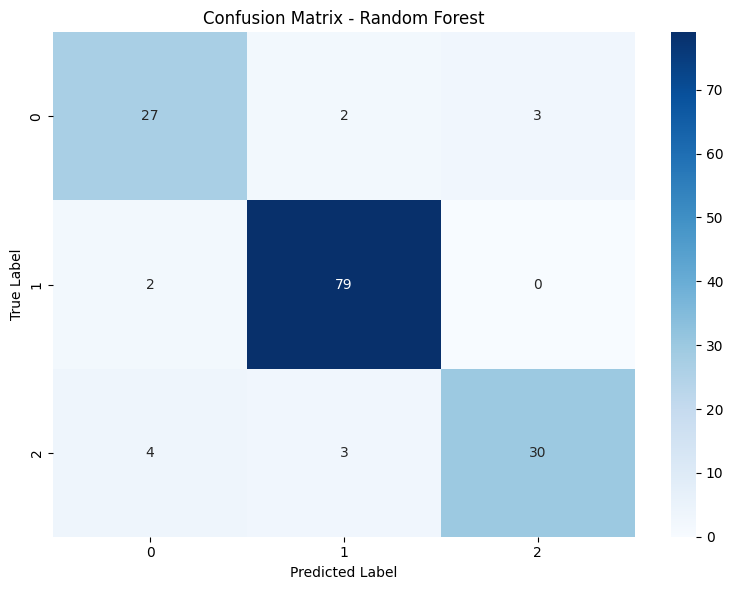

RESULT
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 2
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 2, Predicted: 2
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 1, Predicted: 0
Actual: 2

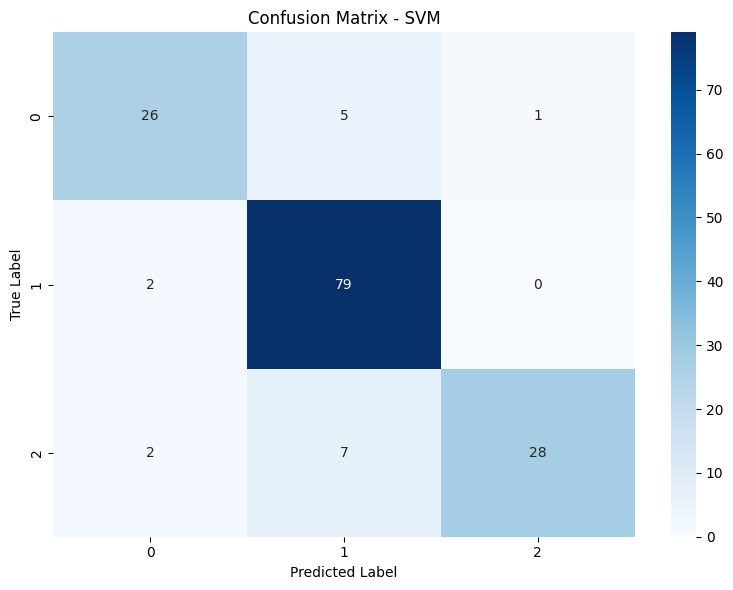


Model Evaluation Metrics:

Random Forest:
Accuracy: 0.9067
F1-score: 0.9067
Cross-validation Score: 0.9444

SVM:
Accuracy: 0.8867
F1-score: 0.8867
Cross-validation Score: 0.9154


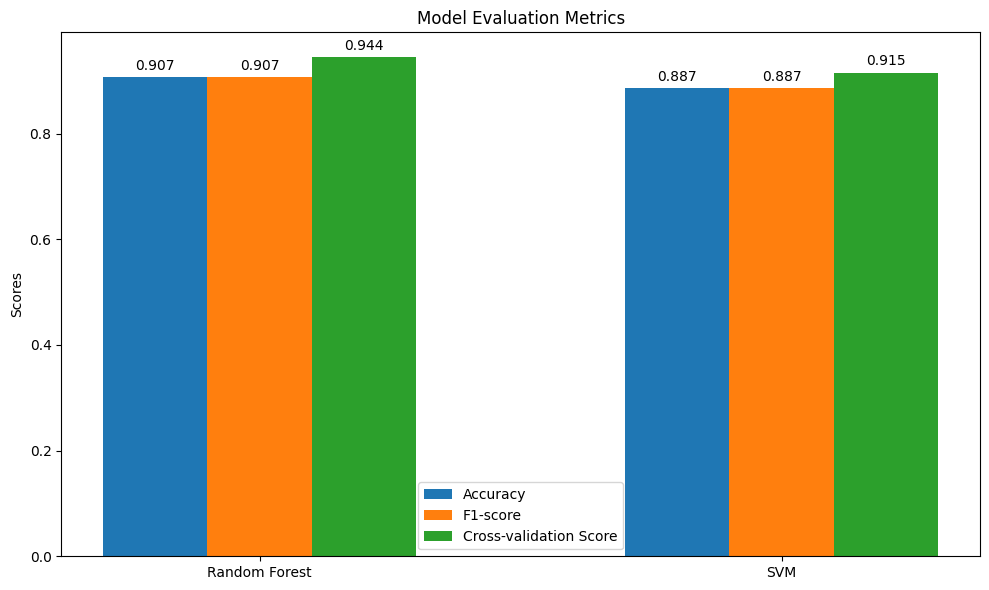


ROC-AUC-OVR for Random Forest:
Class 0: AUC = 0.92
Class 1: AUC = 0.94
Class 2: AUC = 0.91


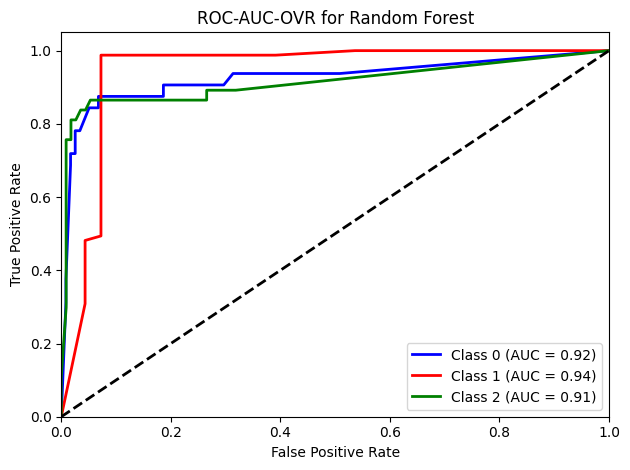


ROC-AUC-OVR for SVM:
Class 0: AUC = 0.89
Class 1: AUC = 0.94
Class 2: AUC = 0.91


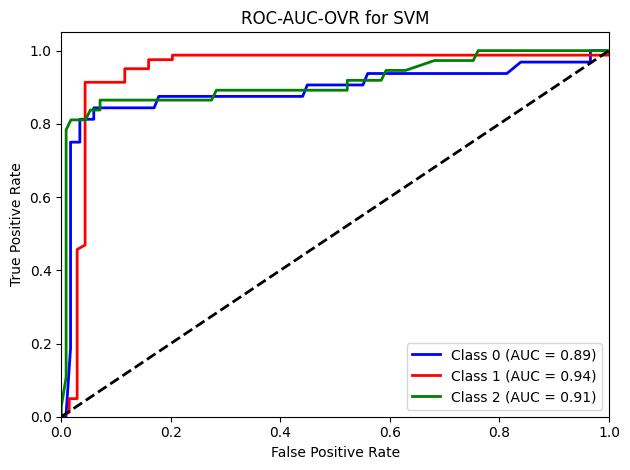

In [ ]:
# Đánh giá 2 mô hình
metrics = {}

accuracy_rf, f1_rf, cv_rf, cm_rf = evaluate_basic_metrics(rf, X_test, y_test, X_train, y_train, model_name="Random Forest")
metrics["Random Forest"] = (accuracy_rf, f1_rf, cv_rf) # Gán lại biến thể ứng với tên mô hình RF

accuracy_svm, f1_svm, cv_svm, cm_svm = evaluate_basic_metrics(svm, X_test, y_test, X_train, y_train, model_name="SVM")
metrics["SVM"] = (accuracy_svm, f1_svm, cv_svm) # Gán lại biến thể ứng với tên mô hình SVM

# So sánh trực quan các metric
metric_comparison(metrics)

# KFold đánh giá chi tiết hơn
evaluate_kfold_scores({"Random Forest": rf}, X_train, y_train)
evaluate_kfold_scores({"SVM": svm}, X_train, y_train)

# ROC-AUC cho mô hình đa lớp (nếu có thể predict_proba)
evaluate_roc_ovr({"Random Forest": rf, "SVM": svm}, X_test, y_test, class_labels=[0, 1, 2])

Lưu mô hình tốt nhất

In [ ]:
joblib.dump(rf,"rf_model.pkl")

['rf_model.pkl']